# Анализ базы данных FIFA ⚽

### Постановка задачи

Обучить модель предсказывать рейтинг игрока по его основным показателям и сравнить с уже данным рейтингом.<br>
Ключевая переменная - OVA<br>
Переменная обучения - Skill level<br>

### Импорт библиотек

In [49]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN 
# KMeans - Алгоритм кластеризации
# AgglomerativeClustering-Иерархическая кластеризация
# DBSCAN - Кластеризация на основе плотности
from sklearn.mixture import GaussianMixture # вероятностная модель кластеризации
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score, accuracy_score, classification_report # Метрики качества
import joblib # Сохранение модели
import warnings
warnings.filterwarnings('ignore') # отключаются все предупреждения от библиотек

### Загрузка данных

In [50]:
df = pd.read_csv(r'C:\Users\тимур\Desktop\fifa\FIFA_raw_data.csv') # считывается файл с данными

In [80]:
df.isnull().sum() # Проверка на наличие пропусков
df.drop_duplicates()
df.dropna()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,SHO,PAS,DRI,DEF,PHY,Hits,KMeans_Cluster,Agg_Cluster,GMM_Cluster,Skill_Level
205,https://cdn.sofifa.com/players/173/731/21_60.png,Gareth Bale,http://sofifa.com/player/173731/gareth-bale/21...,Wales,RW,G. Bale,30,83,83,"\n\n\n\nTottenham Hotspur\nJun 30, 2021 On Loa...",...,84,82,80,58,73,\n192,2,0,0,High
250,https://cdn.sofifa.com/players/200/888/21_60.png,Danilo Luís Hélio Pereira,http://sofifa.com/player/200888/danilo-luis-he...,Portugal,CDM CM,Danilo Pereira,28,82,82,"\n\n\n\nParis Saint-Germain\nJun 30, 2021 On L...",...,63,72,73,80,85,\n122,2,0,0,High
257,https://cdn.sofifa.com/players/193/105/21_60.png,Alphonse Areola,http://sofifa.com/player/193105/alphonse-areol...,France,GK,A. Areola,27,82,86,"\n\n\n\nFulham\nJun 30, 2021 On Loan\n\n",...,79,80,84,55,78,\n68,2,0,2,High
299,https://cdn.sofifa.com/players/223/959/21_60.png,Lucas Torreira,http://sofifa.com/player/223959/lucas-torreira...,Uruguay,CDM CM,L. Torreira,24,81,85,"\n\n\n\nAtlético Madrid\nJun 30, 2021 On Loan\n\n",...,67,75,79,79,74,\n115,2,0,1,High
305,https://cdn.sofifa.com/players/216/409/21_60.png,Matteo Politano,http://sofifa.com/player/216409/matteo-politan...,Italy,RM RW ST,M. Politano,26,81,81,"\n\n\n\nNapoli\nJun 30, 2021 On Loan\n\n",...,77,78,84,42,55,\n69,2,0,0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18497,https://cdn.sofifa.com/players/242/601/21_60.png,Moudi Najjar,http://sofifa.com/player/242601/moudi-najjar/2...,Australia,ST,M. Najjar,20,52,65,"\n\n\n\nMacarthur FC\nAug 31, 2021 On Loan\n\n",...,51,39,53,21,52,2,3,1,3,Low
18569,https://cdn.sofifa.com/players/240/392/21_60.png,Yubiao Deng,http://sofifa.com/player/240392/yubiao-deng/21...,China PR,CM,Deng Yubiao,23,51,60,"\n\n\n\nShijiazhuang Ever Bright F.C.\nDec 31,...",...,42,52,54,47,52,2,3,1,2,Low
18580,https://cdn.sofifa.com/players/236/818/21_60.png,Arthur Read,http://sofifa.com/player/236818/arthur-read/21...,England,CM RW LW,A. Read,20,51,63,"\n\n\n\nStevenage\nJun 30, 2021 On Loan\n\n",...,45,52,59,38,48,3,3,1,2,Low
18638,https://cdn.sofifa.com/players/252/516/21_60.png,Pu Chen,http://sofifa.com/player/252516/pu-chen/210005/,China PR,CAM LM,Chen Pu,23,51,60,"\n\n\n\nShijiazhuang Ever Bright F.C.\nDec 31,...",...,41,55,49,34,47,1,3,1,2,Low


### Вывод информации о данных

In [75]:
df.head() # первые 5 записей

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,SHO,PAS,DRI,DEF,PHY,Hits,KMeans_Cluster,Agg_Cluster,GMM_Cluster,Skill_Level
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,92,91,95,38,65,\n372,2,0,0,High
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,93,81,89,35,77,\n344,2,0,0,High
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,92,78,90,52,90,\n86,2,0,3,High
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,86,93,88,64,78,\n163,2,0,0,High
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,85,86,94,36,59,\n273,2,0,0,High


In [52]:
df.shape[0] 

18979

In [53]:
df.shape[1]

77

In [54]:
df.describe()

,Age,↓OVA,POT,ID,BOV,Growth,Attacking,Crossing,Finishing,Heading Accuracy,...,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,...,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000
mean,25.194583,65.718636,71.136098,226404.790242,66.751620,5.417461,248.938616,49.688551,45.842932,51.941883,...,16.217609,16.519205,1595.293851,355.703040,67.454239,53.457716,57.681069,62.875494,49.865904,64.368618
std,4.710753,6.968999,6.114176,27141.673349,6.747017,5.663954,74.299764,18.131334,19.566978,17.293626,...,17.002134,17.854185,269.883542,40.762282,10.678058,13.827229,10.081914,9.927875,16.442730,9.601665
min,16.000000,47.000000,47.000000,41.000000,48.000000,0.000000,42.000000,6.000000,3.000000,5.000000,...,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000
25%,21.000000,61.000000,67.000000,210135.000000,62.000000,0.000000,222.000000,38.000000,30.000000,44.000000,...,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000
50%,25.000000,66.000000,71.000000,232424.000000,67.000000,4.000000,263.000000,54.000000,49.000000,55.000000,...,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,65.000000
75%,29.000000,70.000000,75.000000,246925.500000,71.000000,9.000000,297.000000,63.000000,62.000000,64.000000,...,14.000000,14.000000,1781.000000,384.000000,75.000000,64.000000,64.000000,69.000000,63.000000,71.000000
max,53.000000,93.000000,95.000000,259216.000000,93.000000,26.000000,437.000000,94.000000,95.000000,93.000000,...,91.000000,90.000000,2316.000000,498.000000,96.000000,93.000000,93.000000,95.000000,91.000000,91.000000


photoUrl - ссылка на фото игрока <br>
LongName - полное официальное имя игрока <br>
playerUrl - ссылка на профиль игрока <br>
Nationality - национальность/страна игрока <br>
Positions - игровые позиции (ST, CAM, CB, GK и т.д.) <br>
Name - краткое имя игрока <br>
ID - уникальный идентификатор игрока <br>
Age - возраст игрока (лет) <br>
Height - рост игрока <br>
Weight - вес игрока <br>
foot - предпочитаемая нога (Left/Right) <br>
↓OVA - общий рейтинг игрока (текущий уровень, 0-99) <br>
POT - потенциальный рейтинг (максимально возможный, 0-99) <br>
BOV - лучший общий рейтинг по позиции <br>
BP - лучшая позиция игрока <br>
Growth - потенциал роста (разница между POT и OVA) <br>
Team & Contract - команда и контрактная информация <br>
Joined - дата присоединения к текущей команде <br>
Loan Date End - дата окончания аренды (если в аренде) <br>
Value - рыночная стоимость игрока (€M/€K) <br>
Wage - недельная зарплата (€K) <br>
Release Clause - сумма отступных по контракту <br>
Attacking - общая атакующая способность (0-100) <br>
Crossing - точность навесов/подач (0-100) <br>
Finishing - реализация голевых моментов (0-100) <br>
Heading Accuracy - точность игры головой (0-100) <br>
Short Passing - точность коротких передач (0-100) <br>
Volleys - удары с лёта (0-100) <br>
Skill - общая техническая способность (0-100) <br>
Dribbling - ведение мяча/дриблинг (0-100) <br>
Curve - умение закручивать мяч (0-100) <br>
FK Accuracy - точность штрафных ударов (0-100) <br>
Long Passing - точность длинных передач (0-100) <br>
Ball Control - контроль мяча/первый касание (0-100) <br>
Movement - общее передвижение (0-100) <br>
Acceleration - ускорение/разгон (0-100) <br>
Sprint Speed - максимальная скорость (0-100) <br>
Agility - ловкость/маневренность (0-100) <br>
Reactions - реакция на игровые ситуации (0-100) <br>
Balance - равновесие/устойчивость (0-100) <br>
Power - общая физическая сила (0-100) <br>
Shot Power - сила удара (0-100) <br>
Jumping - высота прыжка (0-100) <br>
Stamina - выносливость (0-100) <br>
Strength - физическая сила/масса тела (0-100) <br>
Long Shots - точность ударов издалека (0-100) <br>
Mentality - общая ментальная способность (0-100) <br>
Aggression - агрессивность/напористость (0-100) <br>
Interceptions - перехваты мяча (0-100) <br>
Positioning - позиционирование/выбор позиции (0-100) <br>
Vision - видение поля/пас (0-100) <br>
Penalties - точность пенальти (0-100) <br>
Composure - хладнокровие/самообладание (0-100) <br>
Defending - общая защитная способность (0-100) <br>
Marking - опека соперника (0-100) <br>
Standing Tackle - отбор мяча стоя (0-100) <br>
Sliding Tackle - отбор мяча в подкате (0-100) <br>
Goalkeeping - общая вратарская способность (0-100) <br>
GK Diving - нырки/сейвы вратаря (0-100) <br>
GK Handling - ловля/удержание мяча (0-100) <br>
GK Kicking - удары/выбросы вратаря (0-100) <br>
GK Positioning - позиционирование вратаря (0-100) <br>
GK Reflexes - рефлексы/реакция вратаря (0-100) <br>
Total Stats - общая сумма всех атрибутов <br>
Base Stats - базовые статы карты (PAC+SHO+PAS+DRI+DEF+PHY) <br>
Hits - количество просмотров профиля <br>
W/F - рейтинг слабой ноги (1-5 звезд) <br>
SM - финты/скилл мувы (1-5 звезд) <br>
A/W - атакующий work rate (Low/Medium/High) <br>
D/W - защитный work rate (Low/Medium/High) <br>
IR - международная репутация (1-5 звезд) <br>
PAC - общая скорость (Pace, 0-100) <br>
SHO - общий удар (Shooting, 0-100) <br>
PAS - общий пас (Passing, 0-100) <br>
DRI - общий дриблинг (Dribbling, 0-100) <br>
DEF - общая защита (Defending, 0-100) <br>
PHY - общая физика (Physicality, 0-100) <br>

В общей сложности 55 колон

## Визуализация 

### Визуализация распределения

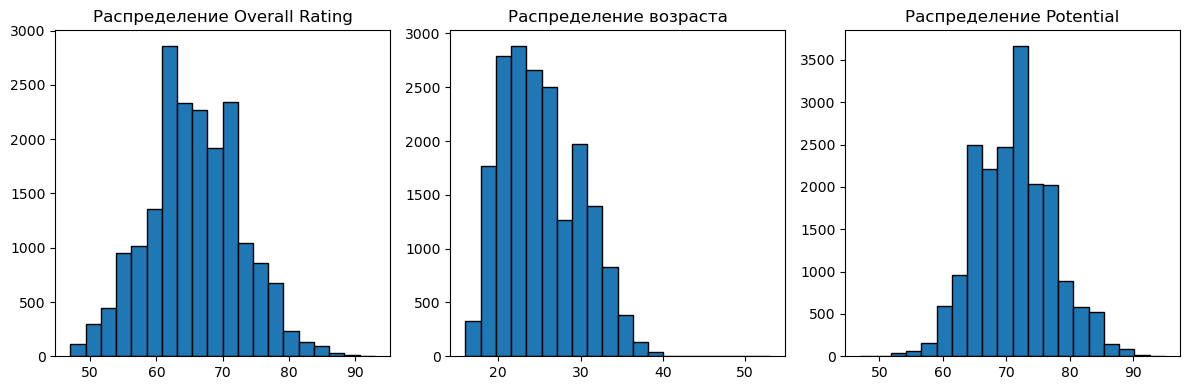

In [55]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(df['↓OVA'].dropna(), bins=20, edgecolor='black')
plt.title('Распределение Overall Rating')

plt.subplot(1, 3, 2)
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')
plt.title('Распределение возраста')

plt.subplot(1, 3, 3)
plt.hist(df['POT'].dropna(), bins=20, edgecolor='black')
plt.title('Распределение Potential')
plt.tight_layout()
plt.show()

### Визуализация топ-10 корреляций

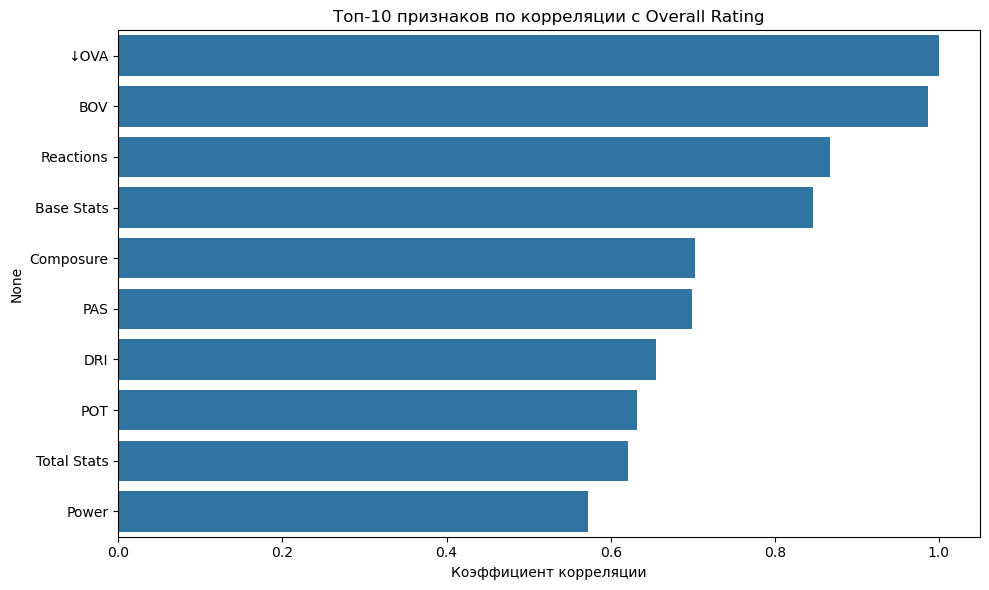

In [59]:
plt.figure(figsize=(10, 6))
top_corr = corr_with_ova.head(10)
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Топ-10 признаков по корреляции с Overall Rating')
plt.xlabel('Коэффициент корреляции')
plt.tight_layout()
plt.show()

## Подготовка данных для кластеризации

In [60]:
cluster_features = ['↓OVA', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Age'] # берутся колонки для кластеризации
X_cluster = df[cluster_features].dropna() # удаляются пропуски
X_scaled = StandardScaler().fit_transform(X_cluster)

In [61]:
# Выбор числовых признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_ova = df[numeric_cols].corrwith(df['↓OVA']).dropna().sort_values(ascending=False)
print(corr_with_ova.head(10))

↓OVA           1.000000
BOV            0.987149
Reactions      0.866954
Base Stats     0.845904
Composure      0.703048
PAS            0.698820
DRI            0.654792
POT            0.632130
Total Stats    0.620846
Power          0.572814
dtype: float64


In [62]:
# Метод 1: K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f"\nK-Means Silhouette Score: {kmeans_score:.3f}")


K-Means Silhouette Score: 0.189


In [63]:
# Метод 2: Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)
df['Agg_Cluster'] = agg.fit_predict(X_scaled)
agg_score = silhouette_score(X_scaled, df['Agg_Cluster'])
print(f"Agglomerative Silhouette Score: {agg_score:.3f}")

Agglomerative Silhouette Score: 0.137


In [64]:
# Метод 3: Gaussian Mixture
gmm = GaussianMixture(n_components=4, random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(X_scaled)
gmm_score = silhouette_score(X_scaled, df['GMM_Cluster'])
print(f"Gaussian Mixture Silhouette Score: {gmm_score:.3f}")

Gaussian Mixture Silhouette Score: 0.079


## Визуализация кластеризации 

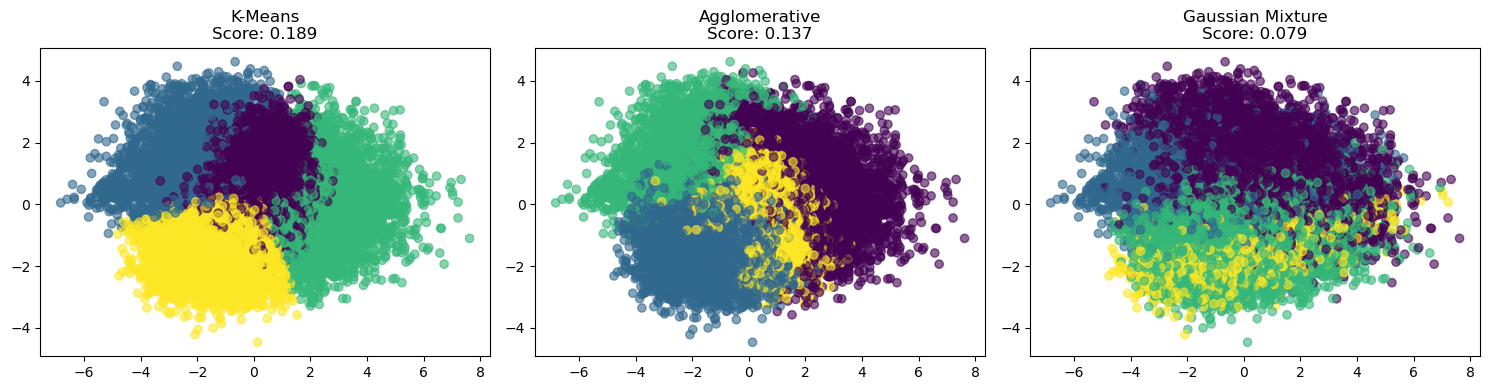

In [65]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
plt.title(f'K-Means\nScore: {kmeans_score:.3f}')

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Agg_Cluster'], cmap='viridis', alpha=0.6)
plt.title(f'Agglomerative\nScore: {agg_score:.3f}')

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['GMM_Cluster'], cmap='viridis', alpha=0.6)
plt.title(f'Gaussian Mixture\nScore: {gmm_score:.3f}')

plt.tight_layout()
plt.show()

## Анализ кластеров

КЛАСТЕР 0
Средний возраст: 28.8
Средний Overall: 66.2
Средний Potential: 67.5
Топ-3 игрока:
        Name  ↓OVA  POT Positions
  N. Pallois    78   78        CB
Jorge Molina    78   78        ST
      Hilton    77   77        CB
КЛАСТЕР 1
Средний возраст: 24.6
Средний Overall: 63.4
Средний Potential: 69.6
Топ-3 игрока:
      Name  ↓OVA  POT Positions
K. Manolas    83   84        CB
  S. Savić    81   82        CB
  J. Evans    80   80        CB
КЛАСТЕР 2
Средний возраст: 26.0
Средний Overall: 73.8
Средний Potential: 77.5
Топ-3 игрока:
             Name  ↓OVA  POT Positions
         L. Messi    93   93  RW ST CF
Cristiano Ronaldo    92   92     ST LW
         J. Oblak    91   93        GK
КЛАСТЕР 3
Средний возраст: 21.0
Средний Overall: 59.4
Средний Potential: 70.2
Топ-3 игрока:
           Name  ↓OVA  POT Positions
      A. Hodžić    73   77        ST
Macarinho Louro    71   71     LM CM
     F. Diabaté    71   75  LM RM ST


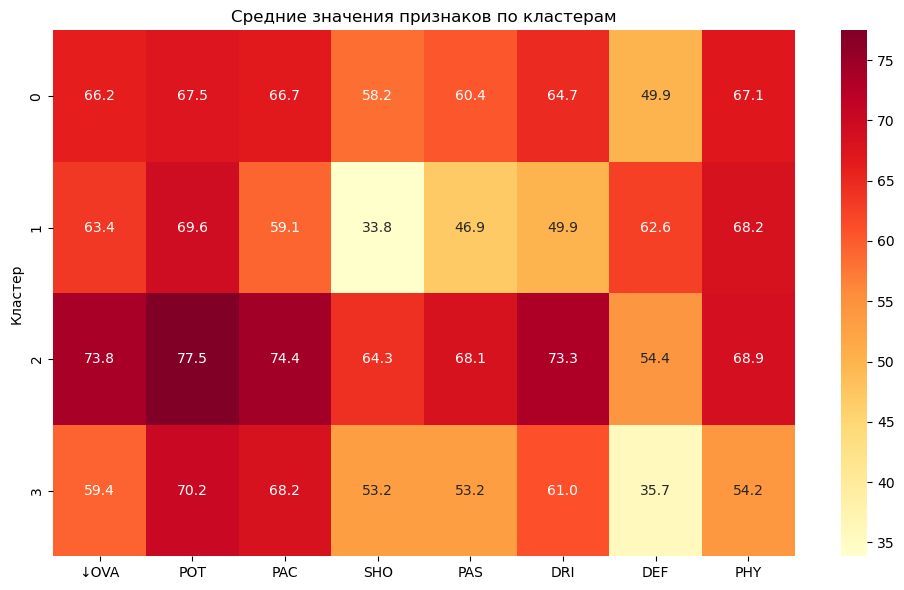

In [66]:
for cluster in range(4):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    print(f"КЛАСТЕР {cluster}")
    print(f"Средний возраст: {cluster_data['Age'].mean():.1f}")
    print(f"Средний Overall: {cluster_data['↓OVA'].mean():.1f}")
    print(f"Средний Potential: {cluster_data['POT'].mean():.1f}")
    print(f"Топ-3 игрока:")
    top_players = cluster_data.nlargest(3, '↓OVA')[['Name', '↓OVA', 'POT', 'Positions']]
    print(top_players.to_string(index=False))

# Визуализация средних значений по кластерам
cluster_means = df.groupby('KMeans_Cluster')[['↓OVA', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Средние значения признаков по кластерам')
plt.ylabel('Кластер')
plt.tight_layout()
plt.show()

## Визуализация по национальностям

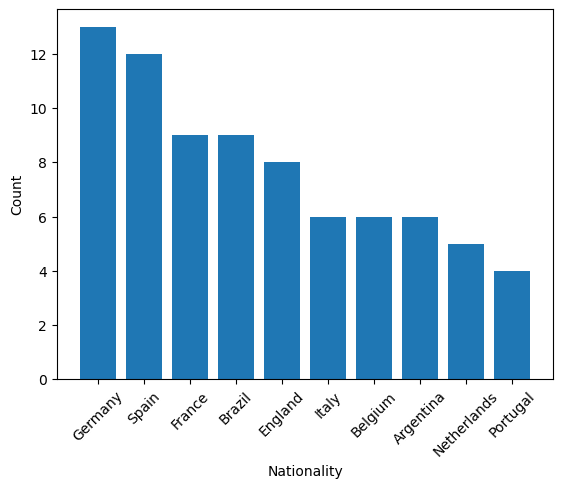

In [67]:
df100 = df.sort_values(by="↓OVA", ascending=False)
df100 = df100[0:100]

nationality_counts = df100.groupby("Nationality").size().reset_index(name="Count")
nationality_counts = nationality_counts.sort_values(by="Count", ascending=False)
nationality_counts = nationality_counts[0:10]

plt.bar(nationality_counts["Nationality"], nationality_counts["Count"])
plt.xlabel("Nationality")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Классификация

### Подготовка данных

In [68]:
df['Skill_Level'] = pd.cut(df['↓OVA'], bins=[0, 70, 80, 100], labels=['Low', 'Medium', 'High']) # Создаем целевую переменную: высокий/средний/низкий

X = df[['Age', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Growth']].dropna()
y = df.loc[X.index, 'Skill_Level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Методы

In [69]:
# Метод 1: Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"\nDecision Tree Accuracy: {dt_acc:.3f}")
print(classification_report(y_test, dt_pred))

# Метод 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"\nRandom Forest Accuracy: {rf_acc:.3f}")
print(classification_report(y_test, rf_pred))

# Метод 3: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"\nLogistic Regression Accuracy: {lr_acc:.3f}")
print(classification_report(y_test, lr_pred))


Decision Tree Accuracy: 0.942
              precision    recall  f1-score   support

        High       0.78      0.68      0.72        74
         Low       0.97      0.97      0.97      2913
      Medium       0.86      0.87      0.87       809

    accuracy                           0.94      3796
   macro avg       0.87      0.84      0.85      3796
weighted avg       0.94      0.94      0.94      3796


Random Forest Accuracy: 0.987
              precision    recall  f1-score   support

        High       0.93      0.92      0.93        74
         Low       0.99      0.99      0.99      2913
      Medium       0.97      0.97      0.97       809

    accuracy                           0.99      3796
   macro avg       0.96      0.96      0.96      3796
weighted avg       0.99      0.99      0.99      3796


Logistic Regression Accuracy: 0.974
              precision    recall  f1-score   support

        High       0.07      0.03      0.04        74
         Low       1.00      1

### Визуализация важности признаков

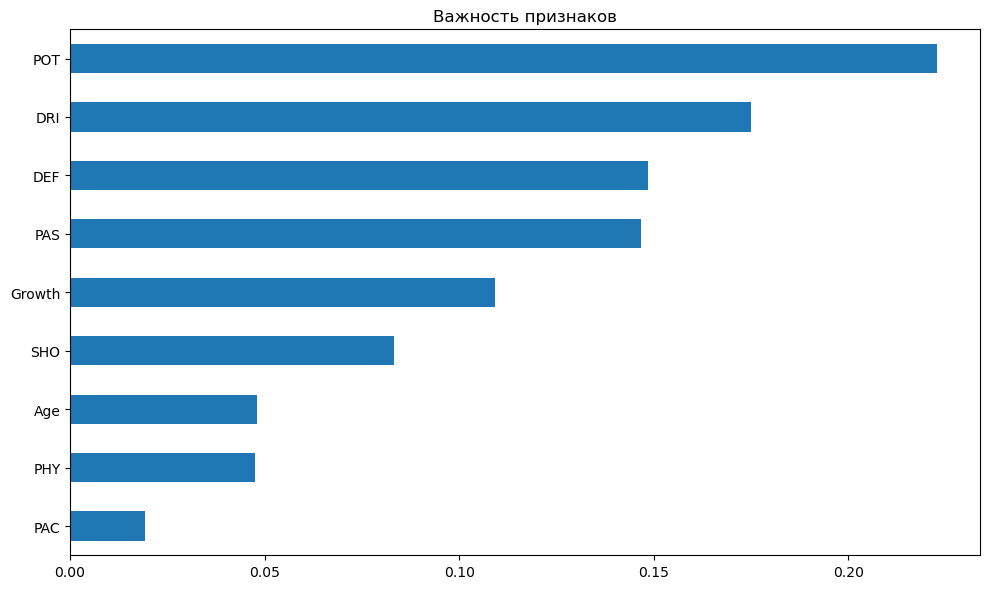

In [70]:
plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Важность признаков')
plt.tight_layout()
plt.show()

### Сравнение моделей

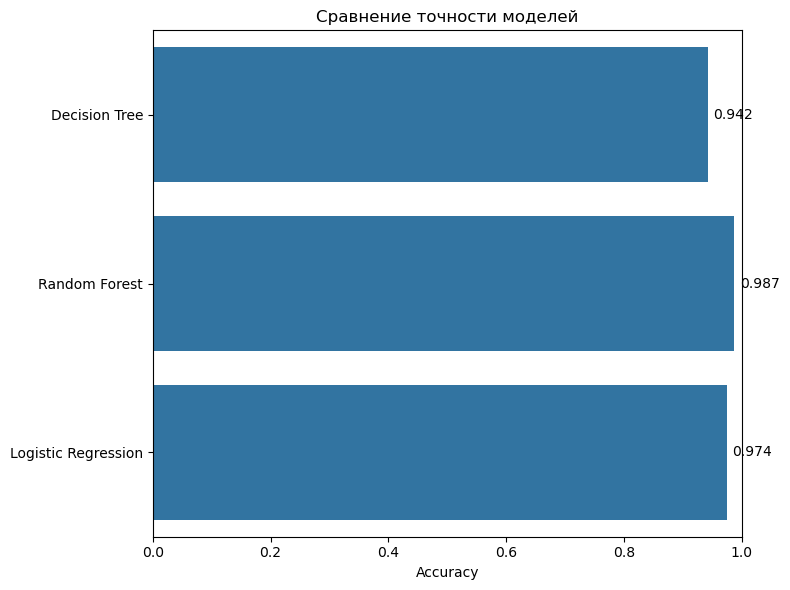

In [71]:
plt.figure(figsize=(8, 6))
models = ['Decision Tree', 'Random Forest', 'Logistic Regression']
accuracies = [dt_acc, rf_acc, lr_acc]
sns.barplot(x=accuracies, y=models)
plt.title('Сравнение точности моделей')
plt.xlabel('Accuracy')
plt.xlim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## Сохранение в файл

In [73]:
with open(r'C:\Users\тимур\Desktop\fifa\FIFA_raw_data.csv', 'r', encoding='utf-8') as f:
    lines = f.readlines()

with open(r'C:\Users\тимур\Desktop\fifa\fifa.csv', 'w', encoding='utf-8') as f:
    f.writelines(lines[:1500])
# Сохраняем лучшую модель
best_model = rf if rf_acc == max(accuracies) else (dt if dt_acc > lr_acc else lr)
joblib.dump(best_model, r'C:\Users\тимур\Desktop\fifa\fifa_classification_model.pkl')
print(f"\nМодель сохранена: fifa_classification_model.pkl")
print(f"Лучшая модель: {'Random Forest' if best_model == rf else ('Decision Tree' if best_model == dt else 'Logistic Regression')}")
print(f"Точность: {max(accuracies):.3f}")


Модель сохранена: fifa_classification_model.pkl
Лучшая модель: Random Forest
Точность: 0.987
